# Figure 1C-F Minimal Recreation

This notebook only rebuilds the four Figure 1 panels shown here:

- panel C: stacked overview with TMB, FGA, clinical tracks, variants, and CNVs
- panels D-F: relapse-group boxplots for TMB, FGA, and aneuploidy

The notebook is intentionally self-contained, but it expects one already-clean clinical TSV that lives outside this repo. No raw clinical parsing, date coercion, stage cleanup, or histology remapping happens here.

Only two 120-month clinical fields are needed for these plots:

- `relapse_120m`: panel C relapse track and the panel D-F grouping
- `distant_met_120m`: panel C distant-metastasis track and sample ordering

How the staged upstream inputs are produced:

- `02_somatic_vcf/vcf_gen_v3.sh` and `02_somatic_vcf/filter_vcfs.sh` create the filtered somatic VCFs used for the variant matrix and TMB
- `04_clincnv_runs/combined_s100_l3_f1/build_pair_subsets.py`, `build_subset_coverages.py`, `launch_split_runs.sh`, and `build_combined_run.py` recreate the combined `combined_bed_split_s100_l3_f1` ClinCNV tree
- `04_clincnv_runs/combined_s100_l3_f1/build_aneuploidy_scores.py` writes `PANEL_SEQ_ROOT / "new_bed_analysis/hrd_input/hrd_inputs"`
- `ANEUPLOIDY_SNAPSHOT_ROOT = PANEL_SEQ_ROOT / "new_bed_analysis/hrd_input/hrd_inputs_combined_bed_split_s100_l3_f1_20260430"` is the dated staged copy of that output used by this notebook


In [13]:
from pathlib import Path
import glob
import gzip
import os
import re
from collections import OrderedDict, defaultdict
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle
from scipy.stats import mannwhitneyu

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

DEFAULT_NOTEBOOK_DIR = Path("/mnt/myvolume/PanelSeqMelanomaNotebook/analysis")
NOTEBOOK_DIR = Path(os.environ.get("PANELSEQ_NOTEBOOK_DIR", DEFAULT_NOTEBOOK_DIR)).expanduser().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
PANEL_SEQ_ROOT = Path(os.environ.get("PANELSEQ_DATA_ROOT", "/mnt/myvolume/panel_seq")).expanduser().resolve()

FIG1_CLINICAL_PATH = Path(
    os.environ.get(
        "PANELSEQ_FIG1_CLINICAL_PATH",
        str(PANEL_SEQ_ROOT / "figure_inputs/figure1_clinical_minimal.tsv"),
    )
).expanduser().resolve()
VCF_DIR = PANEL_SEQ_ROOT / "new_bed_analysis/vcfs"
COMBINED_CLINCNV_ROOT = PANEL_SEQ_ROOT / "v4_v5_clincnv/new_clincnv_runs/combined_runs/combined_bed_split_s100_l3_f1"
MEL_ANNOTATION_PATH = PANEL_SEQ_ROOT / "v4_v5_clincnv/MEL_Annotation.xlsx"
SHARED_GENE_BEDS = {
    "v4": PANEL_SEQ_ROOT / "v4_v5_clincnv/ssSC_v4.gc.genes.bedcoverage.sorted.bed",
    "v5": PANEL_SEQ_ROOT / "new_bed_analysis/ssSC_v5.gc.genes.bed",
}
PANEL_BED_PATHS = {
    "v4": PANEL_SEQ_ROOT / "v4_v5_clincnv/ssSC_v4.bed",
    "v5": PANEL_SEQ_ROOT / "v4_v5_clincnv/ssSC_v5.bed",
}
ANEUPLOIDY_PARENT_ROOT = PANEL_SEQ_ROOT / "new_bed_analysis/hrd_input"
ANEUPLOIDY_SNAPSHOT_ROOT = ANEUPLOIDY_PARENT_ROOT / "hrd_inputs_combined_bed_split_s100_l3_f1_20260430"
ANEUPLOIDY_MANIFEST_PATH = ANEUPLOIDY_SNAPSHOT_ROOT / "aneuploidy_manifest.tsv"
ANEUPLOIDY_SUMMARY_PATH = ANEUPLOIDY_SNAPSHOT_ROOT / "aneuploidy_results/aneuploidy_score_summary.tsv"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

upstream_scripts = pd.DataFrame(
    [
        {
            "stage": "somatic VCFs",
            "repo_scripts": "02_somatic_vcf/vcf_gen_v3.sh; 02_somatic_vcf/filter_vcfs.sh",
            "staged_output_used_here": str(VCF_DIR),
        },
        {
            "stage": "combined ClinCNV run",
            "repo_scripts": "04_clincnv_runs/combined_s100_l3_f1/build_pair_subsets.py; build_subset_coverages.py; launch_split_runs.sh; build_combined_run.py",
            "staged_output_used_here": str(COMBINED_CLINCNV_ROOT),
        },
        {
            "stage": "aneuploidy snapshot",
            "repo_scripts": "04_clincnv_runs/combined_s100_l3_f1/build_aneuploidy_scores.py",
            "staged_output_used_here": str(ANEUPLOIDY_SNAPSHOT_ROOT),
        },
    ]
)
clinical_schema = pd.DataFrame(
    [
        {"column": "Sample", "meaning": "QHPRG primary tumor code used as the join key"},
        {"column": "relapse_120m", "meaning": "0 or 1 relapse-within-120-month flag"},
        {"column": "distant_met_120m", "meaning": "0 or 1 distant-metastasis-within-120-month flag"},
        {"column": "os_dead", "meaning": "0 or 1 overall-survival status for the panel C track"},
        {"column": "stage_cat", "meaning": "already-simplified stage label: IA, IB, IIA, IIB, IIC, or Unknown"},
        {"column": "histology_cat", "meaning": "already-simplified histology label: SSM, NM, ALM, LMM, Rare, or Unknown"},
        {"column": "age_years", "meaning": "numeric age at diagnosis"},
    ]
)

display(Markdown("## Upstream staged outputs"))
display(upstream_scripts)
display(Markdown("## External clinical file contract"))
display(clinical_schema)


## Upstream staged outputs

,stage,repo_scripts,staged_output_used_here
0,somatic VCFs,02_somatic_vcf/vcf_gen_v3.sh; 02_somatic_vcf/f...,/mnt/myvolume/panel_seq/new_bed_analysis/vcfs
1,combined ClinCNV run,04_clincnv_runs/combined_s100_l3_f1/build_pair...,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...
2,aneuploidy snapshot,04_clincnv_runs/combined_s100_l3_f1/build_aneu...,/mnt/myvolume/panel_seq/new_bed_analysis/hrd_i...


## External clinical file contract

,column,meaning
0,Sample,QHPRG primary tumor code used as the join key
1,relapse_120m,0 or 1 relapse-within-120-month flag
2,distant_met_120m,0 or 1 distant-metastasis-within-120-month flag
3,os_dead,0 or 1 overall-survival status for the panel C...
4,stage_cat,"already-simplified stage label: IA, IB, IIA, I..."
5,histology_cat,"already-simplified histology label: SSM, NM, A..."
6,age_years,numeric age at diagnosis


In [14]:
TARGET_VARIANT_GENES = ["TERT", "BRAF", "NRAS", "NF1", "KIT", "CDKN2A", "TP53", "RAC1", "MAP2K1"]
TARGET_CNV_GENES = [
    "CDKN2C",
    "MCL1",
    "SETDB1",
    "PIK3CA",
    "CCND3",
    "E2F3",
    "IFNGR1",
    "ARID1B",
    "CDKN2A",
    "CDKN2B",
    "MTAP",
    "JAK2",
    "HRAS",
    "ERBB3",
    "CDK4",
    "MDM2",
    "TP53BP1",
    "CD276",
    "PPM1D",
]
REQUIRED_CLINICAL_COLUMNS = [
    "Sample",
    "relapse_120m",
    "distant_met_120m",
    "os_dead",
    "stage_cat",
    "histology_cat",
    "age_years",
]
STRICT_SOMATIC = False
OVERLAP_PADDING = 100
FGA_INTERVAL_PADDING = 100
CNV_CLASSES = ["AMP (CN 3)", "AMP (CN 4-10)", "AMP (CN >10)", "HETDEL", "HOMDEL", "LOH", "Multi_Hit"]

EFFECT_TO_CLASS = {
    "frameshift_variant": "Frame_Shift",
    "inframe_insertion": "In_Frame_Ins",
    "disruptive_inframe_insertion": "In_Frame_Ins",
    "conservative_inframe_insertion": "In_Frame_Ins",
    "inframe_deletion": "In_Frame_Del",
    "disruptive_inframe_deletion": "In_Frame_Del",
    "conservative_inframe_deletion": "In_Frame_Del",
    "missense_variant": "Missense_Mutation",
    "stop_gained": "Nonsense_Mutation",
    "stop_lost": "Nonstop_Mutation",
    "start_lost": "Translation_Start_Site",
    "splice_acceptor_variant": "Splice_Site",
    "splice_donor_variant": "Splice_Site",
    "splice_region_variant": "Splice_Site",
}
SEVERITY_ORDER = [
    "frameshift_variant",
    "stop_gained",
    "stop_lost",
    "splice_acceptor_variant",
    "splice_donor_variant",
    "splice_region_variant",
    "start_lost",
    "inframe_deletion",
    "disruptive_inframe_deletion",
    "conservative_inframe_deletion",
    "inframe_insertion",
    "disruptive_inframe_insertion",
    "conservative_inframe_insertion",
    "missense_variant",
    "promoter",
    "regulatory_region_variant",
    "upstream_gene_variant",
]
SEVERITY_RANK = {effect: rank for rank, effect in enumerate(SEVERITY_ORDER)}
CLASS_SEVERITY = [
    "Frame_Shift_Del",
    "Frame_Shift_Ins",
    "Missense_Mutation",
    "Nonsense_Mutation",
    "Splice_Site",
    "Translation_Start_Site",
    "In_Frame_Del",
    "In_Frame_Ins",
    "Promoter",
]
CLASS_RANK = {klass: rank for rank, klass in enumerate(CLASS_SEVERITY)}
NONSYN_CLASSES = {
    "Missense_Mutation",
    "Nonsense_Mutation",
    "Nonstop_Mutation",
    "Splice_Site",
    "Frame_Shift",
    "Frame_Shift_Ins",
    "Frame_Shift_Del",
    "In_Frame_Ins",
    "In_Frame_Del",
    "Translation_Start_Site",
}
PROMOTER_DISTANCE_BP_DEFAULT = 250
PROMOTER_DISTANCE_BP_TERT = 300

VARIANT_COLORS = {
    "Missense_Mutation": "#72d79a",
    "Nonsense_Mutation": "#1687f8",
    "Splice_Site": "#f1d84b",
    "Frame_Shift_Del": "#8c7851",
    "Frame_Shift_Ins": "#8c7851",
    "In_Frame_Del": "#b84f8a",
    "In_Frame_Ins": "#b84f8a",
    "Translation_Start_Site": "#f28e2b",
    "Promoter": "#8e4ec6",
}
CNV_COLORS = {
    "AMP": "#b30d57",
    "Gain (3)": "#f58aa6",
    "HETDEL": "#73d3f6",
    "HOMDEL": "#0072b2",
    "LOH/Multi_Hit": "#ff8c1a",
}
BIN_NO_COLOR = "#1558c0"
BIN_YES_COLOR = "#b20a56"
OS_COLORS = {"alive": "#2b8cbe", "deceased": "#b20a56"}
STAGE_COLORS = {"IA": "#e6f2ff", "IB": "#b3d7ff", "IIA": "#80bdff", "IIB": "#4da3ff", "IIC": "#1a88ff", "Unknown": "#d9d9d9"}
HISTO_COLORS = {"SSM": "#74c476", "NM": "#fdae6b", "ALM": "#bcbddc", "LMM": "#9edae5", "Rare": "#fd8d3c", "Unknown": "#d9d9d9"}
MISSING_COLOR = "#ffffff"
PRIMARY_BOX_COLORS = {0: "#97a53b", 1: "#00b0ff"}
PRIMARY_BOX_DOT_FACE = "#bdbdbd"
PRIMARY_BOX_DOT_EDGE = "#5f5f5f"


@dataclass
class Figure1Bundle:
    final_df: pd.DataFrame
    patients: list[str]
    variant_genes: list[str]
    cnv_genes: list[str]
    df_variants: pd.DataFrame
    df_cnv_calls: pd.DataFrame
    df_tmb_metric: pd.DataFrame
    df_fga_metric: pd.DataFrame
    df_aneuploidy_metric: pd.DataFrame
    excluded_metric_samples: list[str]
    summary: pd.DataFrame






def plot_stacked_figure1(bundle: Figure1Bundle) -> None:
    age_cmap = mpl.cm.Greens
    final_df = bundle.final_df
    order = bundle.patients
    tmb = bundle.df_tmb_metric.reindex(order)["TMB_per_Mb"].astype(float)
    fga = bundle.df_fga_metric.reindex(order)["FGA_ampdel"].astype(float)
    variant_genes = bundle.variant_genes
    cnv_genes = bundle.cnv_genes

    clinical_tracks = [
        ("relapse", "relapse_120m", "binary"),
        ("distant metastasis", "distant_met_120m", "binary"),
        ("overall survival status", "os_dead", "os"),
        ("stage", "stage_cat", "stage"),
        ("histology", "histology_cat", "histology"),
        ("age", "age_years", "age"),
    ]
    rows = [("clinical", label, column, kind) for label, column, kind in clinical_tracks]
    rows.append(("gap", "", "", ""))
    rows.extend(("variant", gene, "", "") for gene in variant_genes)
    rows.append(("gap", "", "", ""))
    rows.extend(("cnv", gene, "", "") for gene in cnv_genes)

    age_min, age_max = np.nanpercentile(final_df["age_years"], [1, 99])
    fig = plt.figure(figsize=(28, 15), dpi=200)
    grid = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.1, 8.5], hspace=0.03)
    ax_tmb = fig.add_subplot(grid[0])
    ax_fga = fig.add_subplot(grid[1], sharex=ax_tmb)
    ax_heat = fig.add_subplot(grid[2], sharex=ax_tmb)

    x = np.arange(len(order))
    ax_tmb.bar(x, tmb.to_numpy(), width=0.62, color="black", edgecolor="white", linewidth=0.25)
    ax_tmb.set_ylabel("TMB")
    ax_tmb.set_xticks([])
    ax_tmb.tick_params(axis="x", length=0)
    ax_tmb.spines["bottom"].set_visible(True)
    ax_tmb.spines["left"].set_linewidth(1.6)
    ax_tmb.spines["bottom"].set_linewidth(1.6)

    ax_fga.bar(x, fga.to_numpy(), width=0.62, color="black", edgecolor="white", linewidth=0.25)
    ax_fga.set_ylabel("FGA")
    ax_fga.set_xticks([])
    ax_fga.tick_params(axis="x", length=0)
    ax_fga.set_ylim(0, 1.05)
    ax_fga.spines["bottom"].set_visible(True)
    ax_fga.spines["left"].set_linewidth(1.6)
    ax_fga.spines["bottom"].set_linewidth(1.6)

    ax_heat.set_xlim(0, len(order))
    ax_heat.set_ylim(len(rows), 0)
    ax_heat.set_xticks([])
    ax_heat.tick_params(axis="x", length=0)
    ax_heat.tick_params(axis="y", length=0)
    row_centers = []
    row_labels = []

    for row_idx, (kind, label, column, track_kind) in enumerate(rows):
        y0 = row_idx
        if kind == "gap":
            ax_heat.plot([0, len(order)], [y0, y0], color="#8a8a8a", linewidth=1.0)
            row_centers.append(row_idx + 0.5)
            row_labels.append("")
            continue

        for x_idx, patient_id in enumerate(order):
            if kind == "variant":
                face = _color_for_variant(bundle.df_variants.at[patient_id, label])
            elif kind == "cnv":
                face = _color_for_cnv(bundle.df_cnv_calls.at[patient_id, label])
            else:
                value = final_df.at[patient_id, column]
                if track_kind == "binary":
                    face = _color_for_binary(value)
                elif track_kind == "os":
                    face = _color_for_os(value)
                elif track_kind == "stage":
                    face = _color_for_stage(value)
                elif track_kind == "histology":
                    face = _color_for_histology(value)
                else:
                    face = _color_for_age(value, age_min, age_max, age_cmap)
            ax_heat.add_patch(Rectangle((x_idx, y0), 1, 1, facecolor=face, edgecolor="white", linewidth=0.25))

        row_centers.append(row_idx + 0.5)
        row_labels.append(label)

    ax_heat.set_yticks(row_centers)
    ax_heat.set_yticklabels(row_labels, fontsize=11)
    for spine in ax_heat.spines.values():
        spine.set_color("#bdbdbd")
        spine.set_linewidth(1.0)
    plt.show()


def plot_metric_boxplots(bundle: Figure1Bundle) -> None:
    primary_boxplot_patients = sorted(bundle.final_df.index[bundle.final_df["relapse_120m"].isin([0, 1])])
    metrics = [
        ("TMB_per_Mb", bundle.df_tmb_metric, "TMB per Mb"),
        ("FGA_ampdel", bundle.df_fga_metric, "FGA"),
        ("aneuploidy_score", bundle.df_aneuploidy_metric, "Aneuploidy score"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.3), dpi=220)
    for ax, (value_col, metric_df, ylabel) in zip(axes, metrics):
        plot_df = _prepare_metric_for_relapse_plot(bundle.final_df, metric_df, value_col, primary_boxplot_patients)
        _draw_relapse_boxplot(ax, plot_df, value_col, ylabel)
    plt.tight_layout()
    plt.show()


def _count_clincnv_files(clincnv_root: Path) -> int:
    return len(
        set(glob.glob(str(clincnv_root / "**/Annotated_CNA_CNAs_*.txt"), recursive=True))
        | set(glob.glob(str(clincnv_root / "**/Annotated_ClinCNV_*.txt"), recursive=True))
        | set(glob.glob(str(clincnv_root / "**/*_Annotated_ClinCNV.txt"), recursive=True))
    )


def _glob_count(pattern) -> int:
    return len(glob.glob(str(pattern), recursive=True))


def _load_clinical_table(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, sep="\t")
    missing = [column for column in REQUIRED_CLINICAL_COLUMNS if column not in frame.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    final_df = frame[REQUIRED_CLINICAL_COLUMNS].copy().set_index("Sample")
    if final_df.index.duplicated().any():
        duplicates = sorted(final_df.index[final_df.index.duplicated()].unique())
        raise ValueError(f"Clinical input contains duplicated Sample IDs: {duplicates}")

    for column in ["relapse_120m", "distant_met_120m", "os_dead"]:
        final_df[column] = pd.to_numeric(final_df[column], errors="raise")
        values = final_df[column].dropna()
        if not values.isin([0, 1]).all():
            raise ValueError(f"{column} must already be encoded as 0/1 before entering this notebook.")

    final_df["age_years"] = pd.to_numeric(final_df["age_years"], errors="coerce")
    return final_df


def _load_sample_panel_map(path: Path) -> dict[str, str]:
    mel_annotation = pd.read_excel(path, sheet_name="MFT_SINNBERG_QHPRG_MeasTabelle9")
    return (
        mel_annotation[["code", "system_name_short"]]
        .dropna(subset=["code"])
        .assign(
            code=lambda df: df["code"].astype(str).str.strip(),
            system_name_short=lambda df: df["system_name_short"].astype(str).str.strip(),
        )
        .drop_duplicates(subset="code", keep="first")
        .set_index("code")["system_name_short"]
        .to_dict()
    )


def _open_text_maybe_gzip(path):
    path = Path(path)
    if path.suffix == ".gz":
        return gzip.open(path, "rt", encoding="utf-8", errors="ignore")
    return path.open("r", encoding="utf-8", errors="ignore")


def _looks_somatic(info_str: str, strict: bool = False) -> bool:
    markers = ["SOMATIC", "SOMATIC=1", "SS=2", "SSTATUS=Somatic", "SOMATICSCORE", "SOMATIC_SCORE", "TYPE=somatic", "SOMATIC_CALL", "SOMATIC;"]
    hit = any(marker in (info_str or "") for marker in markers)
    return hit if strict else True


def _parse_ann_records(info_value: str) -> list[list[str]]:
    records = []
    for record in info_value.split(","):
        fields = record.split("|")
        while len(fields) < 18:
            fields.append("")
        records.append(fields)
    return records


def _pick_best_effect_for_alt(records: list[list[str]]):
    best_fields = None
    best_effect = None
    best_rank = 10**9
    for fields in records:
        for effect in (fields[1] or "").split("&"):
            effect = effect.strip()
            rank = SEVERITY_RANK.get(effect, 10**9)
            if rank < best_rank:
                best_fields = fields
                best_effect = effect
                best_rank = rank
    return best_fields, best_effect


def _promoter_like_to_class(gene: str, fields: list[str], effect_single: str):
    effect_single = (effect_single or "").strip()
    if effect_single == "promoter":
        return "Promoter"
    if effect_single in {"upstream_gene_variant", "regulatory_region_variant"}:
        try:
            dist = int(fields[14] or "0")
        except ValueError:
            dist = 10**9
        cutoff = PROMOTER_DISTANCE_BP_TERT if gene == "TERT" else PROMOTER_DISTANCE_BP_DEFAULT
        return "Promoter" if dist <= cutoff else None
    return None


def _classify_variant_with_context(gene: str, fields: list[str], effect_single: str, ref: str, alt: str):
    promoter_class = _promoter_like_to_class(gene, fields, effect_single)
    if promoter_class is not None:
        return promoter_class
    if effect_single == "coding_sequence_variant":
        hgvs_p = fields[10] if len(fields) > 10 else ""
        if hgvs_p.startswith("p.=") or hgvs_p == "":
            return None
        return "Missense_Mutation"
    base = EFFECT_TO_CLASS.get((effect_single or "").strip())
    if base is None:
        return None
    if base == "Frame_Shift":
        if len(alt) > len(ref):
            return "Frame_Shift_Ins"
        if len(alt) < len(ref):
            return "Frame_Shift_Del"
        return "Frame_Shift_Ins"
    return base


def _sample_name_from_path(path) -> str:
    base = os.path.basename(str(path))
    if base.startswith("filtered."):
        base = base[len("filtered."):]
    for suffix in (".annotated.vcf.gz", ".annotated.vcf", ".vcf.gz", ".vcf"):
        if base.endswith(suffix):
            return base[: -len(suffix)]
    return base


def _sample_code_from_vcf_path(path) -> str:
    return _sample_name_from_path(path).split("__")[0].strip()


def _merge_intervals_0based(intervals: list[tuple[str, int, int]]) -> dict[str, list[tuple[int, int]]]:
    per_chr = defaultdict(list)
    for chrom, start0, end0 in intervals:
        if start0 < end0:
            per_chr[chrom].append((start0, end0))
    merged = {}
    for chrom, values in per_chr.items():
        values.sort()
        out = []
        for start0, end0 in values:
            if not out or start0 > out[-1][1]:
                out.append([start0, end0])
            else:
                out[-1][1] = max(out[-1][1], end0)
        merged[chrom] = [(start0, end0) for start0, end0 in out]
    return merged


def _load_targets_padded_0based(path: Path, pad: int = 0) -> dict[str, list[tuple[int, int]]]:
    intervals = []
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            chrom = parts[0]
            start0 = max(0, int(parts[1]) - pad)
            end0 = int(parts[2]) + pad
            intervals.append((chrom, start0, end0))
    return _merge_intervals_0based(intervals)


def _territory_bp_0based(merged: dict[str, list[tuple[int, int]]]) -> int:
    return sum(end0 - start0 for chrom in merged for start0, end0 in merged[chrom])


def _overlaps_0based(chrom: str, start0: int, end0: int, merged: dict[str, list[tuple[int, int]]]) -> bool:
    for target_start, target_end in merged.get(chrom, []):
        if target_end <= start0:
            continue
        if target_start >= end0:
            break
        if max(target_start, start0) < min(target_end, end0):
            return True
    return False


def _build_variant_matrix(
    vcf_dir: Path,
    target_genes: list[str],
    sample_panel_map: dict[str, str],
    panel_bed_paths: dict[str, Path],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    panel_targets_overlap = {panel: _load_targets_padded_0based(path, pad=OVERLAP_PADDING) for panel, path in panel_bed_paths.items()}
    panel_targets_territory = {panel: _load_targets_padded_0based(path, pad=0) for panel, path in panel_bed_paths.items()}
    raw_panel_territory_mb = {panel: _territory_bp_0based(targets) / 1e6 for panel, targets in panel_targets_territory.items()}

    vcf_paths = sorted(
        set(glob.glob(str(vcf_dir / "**/filtered.*.annotated.vcf"), recursive=True))
        | set(glob.glob(str(vcf_dir / "**/filtered.*.annotated.vcf.gz"), recursive=True))
    )

    target_set = {gene.upper() for gene in target_genes}
    samples = [_sample_name_from_path(path) for path in vcf_paths]
    hits = {gene: {sample: [] for sample in samples} for gene in target_genes}
    seen = {gene: {sample: set() for sample in samples} for gene in target_genes}
    tmb_records = []

    for sample, path in zip(samples, vcf_paths):
        sample_code = _sample_code_from_vcf_path(path)
        panel_label = str(sample_panel_map.get(sample_code, "")).lower()
        panel_version = "v4" if "v4" in panel_label else "v5"
        overlap_targets = panel_targets_overlap[panel_version]
        denominator_mb = raw_panel_territory_mb[panel_version]
        nonsyn = 0

        with _open_text_maybe_gzip(path) as handle:
            for line in handle:
                if not line or line.startswith("#"):
                    continue
                parts = line.rstrip("\n").split("\t")
                if len(parts) < 8:
                    continue
                chrom, pos, _id, ref, alts, qual, flt, info = parts[:8]
                if flt != "PASS":
                    continue
                if not _looks_somatic(info, strict=STRICT_SOMATIC):
                    continue

                info_dict = {}
                for item in info.split(";"):
                    if not item:
                        continue
                    if "=" in item:
                        key, value = item.split("=", 1)
                        info_dict[key] = value
                    else:
                        info_dict[item] = True
                ann_raw = info_dict.get("ANN")
                if not ann_raw:
                    continue

                start0 = int(pos) - 1
                end0 = start0 + len(ref)
                on_target = _overlaps_0based(chrom, start0, end0, overlap_targets)
                ann_records = _parse_ann_records(ann_raw)
                best_per_gene = {}

                for alt in alts.split(","):
                    records_for_alt = [rec for rec in ann_records if (rec[0] or "").split("/")[0] == alt] or ann_records
                    best_fields, best_effect = _pick_best_effect_for_alt(records_for_alt)
                    if not best_fields or not best_effect:
                        continue
                    gene = (best_fields[3] or "").upper()
                    rank = SEVERITY_RANK.get(best_effect, 10**9)
                    if gene in target_set:
                        prev = best_per_gene.get(gene)
                        if prev is None or rank < prev[0]:
                            best_per_gene[gene] = (rank, best_effect, alt, best_fields)
                    variant_class = _classify_variant_with_context(gene, best_fields, best_effect, ref, alt)
                    if on_target and variant_class in NONSYN_CLASSES:
                        nonsyn += 1

                for gene, (_rank, effect, alt, fields) in best_per_gene.items():
                    variant_class = _classify_variant_with_context(gene, fields, effect, ref, alt)
                    if variant_class is None:
                        continue
                    key = (chrom, pos, ref, alt)
                    if key in seen[gene][sample]:
                        continue
                    seen[gene][sample].add(key)
                    hits[gene][sample].append(variant_class)

        tmb_records.append(
            {
                "Sample": sample_code,
                "Panel_Version": panel_version,
                "TMB_per_Mb": nonsyn / denominator_mb if denominator_mb > 0 else np.nan,
                "Nonsynonymous_Count": nonsyn,
            }
        )

    matrix = OrderedDict()
    for gene in target_genes:
        row = OrderedDict()
        for sample in samples:
            values = sorted(set(hits[gene][sample]))
            row[sample] = "" if not values else min(values, key=lambda klass: CLASS_RANK.get(klass, 999))
        matrix[gene] = row

    df_variants = pd.DataFrame.from_dict({gene: dict(row) for gene, row in matrix.items()}, orient="index").T
    df_variants.index = df_variants.index.str.split("_").str[0]
    df_tmb = pd.DataFrame.from_records(tmb_records).set_index("Sample").sort_index()
    return df_variants, df_tmb


def _merge_intervals(intervals: list[tuple[int, int]]) -> list[tuple[int, int]]:
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        prev_start, prev_end = merged[-1]
        if start <= prev_end:
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))
    return merged


def _load_targets_padded(path: Path, pad: int = 0) -> dict[str, list[tuple[int, int]]]:
    per_chr = defaultdict(list)
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            chrom = parts[0]
            start = max(0, int(parts[1]) - pad)
            end = int(parts[2]) + pad
            if start < end:
                per_chr[chrom].append((start, end))
    return {chrom: _merge_intervals(values) for chrom, values in per_chr.items()}


def _territory_bp(merged_targets: dict[str, list[tuple[int, int]]]) -> int:
    return sum(end - start for chrom in merged_targets for start, end in merged_targets[chrom])


def _clipped_target_overlaps(chrom: str, start: int, end: int, merged_targets: dict[str, list[tuple[int, int]]]) -> list[tuple[int, int]]:
    overlaps = []
    for target_start, target_end in merged_targets.get(chrom, []):
        if target_end <= start:
            continue
        if target_start >= end:
            break
        overlap_start = max(target_start, start)
        overlap_end = min(target_end, end)
        if overlap_start < overlap_end:
            overlaps.append((overlap_start, overlap_end))
    return overlaps


def _union_len(intervals: list[tuple[int, int]]) -> int:
    return sum(end - start for start, end in _merge_intervals(intervals))


def _sample_from_clincnv_path(path) -> str:
    base = os.path.basename(str(path))
    patterns = (
        r"(?:Annotated_CNA_CNAs?|Annotated_ClinCNV)_(.+?)\.txt$",
        r".+?_(QHPRG[^_]+)_Annotated_ClinCNV\.txt$",
    )
    for pattern in patterns:
        match = re.match(pattern, base)
        if match:
            return match.group(1)
    return os.path.splitext(base)[0]


def _read_clincnv_rows(path) -> list[dict[str, str]]:
    header = None
    rows = []
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if line.startswith("##"):
                continue
            if line.startswith("#"):
                header = line.lstrip("#").rstrip("\n").split("\t")
                continue
            if not header or not line.strip():
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < len(header):
                parts += [""] * (len(header) - len(parts))
            elif len(parts) > len(header):
                parts = parts[: len(header)]
            record = dict(zip(header, parts))
            record["_genes_list"] = [gene.strip() for gene in record.get("genes", "").split(",") if gene.strip()]
            rows.append(record)
    return rows


def _to_int_or_none(value):
    try:
        return int(float(value))
    except Exception:
        return None


def _max_total_cn(major1, minor1, major2, minor2):
    values = []
    for maj, mino in ((major1, minor1), (major2, minor2)):
        maj_i = _to_int_or_none(maj)
        min_i = _to_int_or_none(mino)
        if maj_i is not None and min_i is not None:
            values.append(maj_i + min_i)
    return max(values) if values else None


def _classify_two_state_cnv(state, major1, minor1, major2, minor2):
    state = (state or "").strip().upper()
    if state in {"AMP", "GAIN", "DUP"}:
        total_cn = _max_total_cn(major1, minor1, major2, minor2)
        if total_cn is None or total_cn == 3:
            return "AMP (CN 3)"
        if 4 <= total_cn <= 10:
            return "AMP (CN 4-10)"
        if total_cn > 10:
            return "AMP (CN >10)"
        return "AMP (CN 3)"
    if state == "LOH":
        return "LOH"
    if state == "DEL":
        maj1_i = _to_int_or_none(major1)
        min1_i = _to_int_or_none(minor1)
        maj2_i = _to_int_or_none(major2)
        min2_i = _to_int_or_none(minor2)
        homdel = ((maj1_i == 0 and min1_i == 0) or (maj2_i == 0 and min2_i == 0))
        return "HOMDEL" if homdel else "HETDEL"
    return None


def _build_cnv_and_fga(
    clincnv_root: Path,
    sample_panel_map: dict[str, str],
    panel_bed_paths: dict[str, Path],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    clincnv_paths = sorted(
        set(glob.glob(str(clincnv_root / "**/Annotated_CNA_CNAs_*.txt"), recursive=True))
        | set(glob.glob(str(clincnv_root / "**/Annotated_ClinCNV_*.txt"), recursive=True))
        | set(glob.glob(str(clincnv_root / "**/*_Annotated_ClinCNV.txt"), recursive=True))
    )
    per_sample_gene_classes = {}
    class_records = []
    panel_targets = {panel: _load_targets_padded(path, pad=FGA_INTERVAL_PADDING) for panel, path in panel_bed_paths.items()}
    panel_bp = {panel: _territory_bp(targets) for panel, targets in panel_targets.items()}
    fga_records = []

    for path in clincnv_paths:
        sample = _sample_from_clincnv_path(path)
        gene_classes = defaultdict(set)
        by_chr = defaultdict(list)
        sample_code = sample.split("-")[0]
        panel_label = str(sample_panel_map.get(sample_code, "")).lower()
        panel_version = "v4" if "v4" in panel_label else "v5"
        merged_targets = panel_targets[panel_version]

        for row in _read_clincnv_rows(path):
            cnv_class = _classify_two_state_cnv(
                row.get("state", ""),
                row.get("major_CN_allele", ""),
                row.get("minor_CN_allele", ""),
                row.get("major_CN_allele2", ""),
                row.get("minor_CN_allele2", ""),
            )
            if cnv_class:
                for gene in row.get("_genes_list", []):
                    gene_classes[gene].add(cnv_class)

            chrom = row.get("chr") or row.get("#chr") or row.get("chrom") or row.get("Chromosome")
            chrom = str(chrom)
            if chrom and not chrom.startswith("chr"):
                chrom = f"chr{chrom}"
            if chrom not in merged_targets:
                continue
            try:
                start = int(row.get("start", "0"))
                end = int(row.get("end", "0"))
            except Exception:
                continue
            if start >= end:
                continue
            state = (row.get("state") or "").upper()
            if state in {"AMP", "DEL"}:
                by_chr[chrom].extend(_clipped_target_overlaps(chrom, start, end, merged_targets))

        per_sample_gene_classes[sample] = gene_classes
        multi_hit_genes = {gene for gene, classes in gene_classes.items() if len(classes) > 1}
        record = {"Sample": sample}
        for klass in CNV_CLASSES[:-1]:
            record[klass] = ", ".join(sorted(gene for gene, classes in gene_classes.items() if len(classes) == 1 and klass in classes))
        record["Multi_Hit"] = ", ".join(sorted(multi_hit_genes))
        class_records.append(record)

        altered_bp = sum(_union_len(by_chr.get(chrom, [])) for chrom in merged_targets)
        fga_records.append(
            {
                "Sample": sample_code,
                "Panel_Version": panel_version,
                "FGA_ampdel": altered_bp / panel_bp[panel_version] if panel_bp[panel_version] else np.nan,
            }
        )

    df_cnv_by_class = pd.DataFrame(class_records).set_index("Sample").sort_index()
    all_cnv_genes = sorted({gene for classes in per_sample_gene_classes.values() for gene in classes})
    df_cnv_calls = pd.DataFrame(index=df_cnv_by_class.index, columns=all_cnv_genes, dtype=object)
    df_cnv_calls[:] = np.nan
    for sample, gene_to_classes in per_sample_gene_classes.items():
        for gene, classes in gene_to_classes.items():
            df_cnv_calls.at[sample, gene] = "Multi_Hit" if len(classes) > 1 else next(iter(classes))

    df_fga = pd.DataFrame.from_records(fga_records).set_index("Sample").sort_index()
    return df_cnv_calls, df_fga




def _load_bed_gene_set(path: Path, gene_col: int = 4) -> set[str]:
    bed = pd.read_csv(path, sep="\t", header=None, usecols=[gene_col])
    genes = set()
    for raw in bed.iloc[:, 0].dropna():
        for gene in str(raw).split(","):
            gene = gene.strip()
            if gene and gene != ".":
                genes.add(gene.upper())
    return genes


def _collapse_metric_df(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    metric = df[[value_col]].copy()
    metric[value_col] = pd.to_numeric(metric[value_col], errors="coerce")
    return metric.groupby(metric.index)[value_col].median().to_frame()


def _keep_nonempty_columns(frame: pd.DataFrame) -> pd.DataFrame:
    mask = frame.fillna("").astype(str).apply(lambda col: col.str.strip().ne("").any())
    return frame.loc[:, mask]


def _reduce_pair_index_to_tumor_code(frame: pd.DataFrame) -> pd.DataFrame:
    base_ids = frame.index.to_series().astype(str).str.split("-", n=1).str[0]
    nan_counts = frame.isna().sum(axis=1)
    tmp = frame.copy()
    tmp["__base_id"] = base_ids.values
    tmp["__nan_count"] = nan_counts.values
    tmp = tmp.sort_values("__nan_count").drop_duplicates(subset="__base_id", keep="first")
    tmp = tmp.set_index("__base_id").drop(columns="__nan_count")
    return tmp


def _has_variant(patient_id: str, gene: str, variant_df: pd.DataFrame) -> bool:
    if gene not in variant_df.columns or patient_id not in variant_df.index:
        return False
    value = variant_df.at[patient_id, gene]
    return (not pd.isna(value)) and (str(value).strip() != "")


def _relapse_group(patient_id: str, final_df: pd.DataFrame) -> int:
    relapse = final_df.at[patient_id, "relapse_120m"]
    distant = final_df.at[patient_id, "distant_met_120m"]
    relapse = int(relapse) if not pd.isna(relapse) else None
    distant = int(distant) if not pd.isna(distant) else None
    if relapse == 0 and distant == 0:
        return 0
    if relapse == 1 and distant == 0:
        return 1
    if relapse == 1 and distant == 1:
        return 2
    return 3


def _sort_key(patient_id: str, final_df: pd.DataFrame, df_variants: pd.DataFrame):
    return (
        _relapse_group(patient_id, final_df),
        0 if _has_variant(patient_id, "TERT", df_variants) else 1,
        0 if _has_variant(patient_id, "BRAF", df_variants) else 1,
        0 if _has_variant(patient_id, "NRAS", df_variants) else 1,
        0 if _has_variant(patient_id, "NF1", df_variants) else 1,
        0 if _has_variant(patient_id, "CDKN2A", df_variants) else 1,
        str(patient_id),
    )


def _color_for_variant(value):
    if pd.isna(value) or str(value).strip() == "":
        return MISSING_COLOR
    return VARIANT_COLORS.get(str(value).strip(), "#999999")


def _color_for_cnv(value):
    if pd.isna(value) or str(value).strip() == "":
        return MISSING_COLOR
    value = str(value).strip()
    if value in {"LOH", "Multi_Hit"}:
        return CNV_COLORS["LOH/Multi_Hit"]
    if value == "AMP (CN 3)":
        return CNV_COLORS["Gain (3)"]
    if value.startswith("AMP"):
        return CNV_COLORS["AMP"]
    return CNV_COLORS.get(value, "#999999")


def _color_for_binary(value):
    if pd.isna(value):
        return MISSING_COLOR
    return BIN_YES_COLOR if int(value) == 1 else BIN_NO_COLOR


def _color_for_os(value):
    if pd.isna(value):
        return MISSING_COLOR
    return OS_COLORS["deceased"] if int(value) == 1 else OS_COLORS["alive"]


def _color_for_stage(value):
    if pd.isna(value):
        return MISSING_COLOR
    return STAGE_COLORS.get(str(value), STAGE_COLORS["Unknown"])


def _color_for_histology(value):
    if pd.isna(value):
        return MISSING_COLOR
    return HISTO_COLORS.get(str(value), HISTO_COLORS["Unknown"])


def _color_for_age(value, vmin, vmax, cmap):
    if pd.isna(value):
        return MISSING_COLOR
    scaled = 0.5 if vmax <= vmin else min(max((float(value) - vmin) / (vmax - vmin), 0), 1)
    red, green, blue, _alpha = cmap(scaled)
    return "#{:02x}{:02x}{:02x}".format(int(red * 255), int(green * 255), int(blue * 255))


def _prepare_metric_for_relapse_plot(final_df: pd.DataFrame, metric_df: pd.DataFrame, value_col: str, cohort_ids: list[str]) -> pd.DataFrame:
    plot_df = final_df.loc[cohort_ids, ["relapse_120m"]].join(metric_df[[value_col]].reindex(cohort_ids), how="left")
    plot_df = plot_df[plot_df["relapse_120m"].isin([0, 1])].copy()
    plot_df["relapse_120m"] = plot_df["relapse_120m"].astype(int)
    plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[value_col]).copy()
    return plot_df


def _draw_relapse_boxplot(ax, plot_df: pd.DataFrame, value_col: str, ylabel: str):
    group0 = plot_df.loc[plot_df["relapse_120m"] == 0, value_col]
    group1 = plot_df.loc[plot_df["relapse_120m"] == 1, value_col]
    pval = mannwhitneyu(group0, group1, alternative="two-sided").pvalue if len(group0) and len(group1) else np.nan

    rng = np.random.default_rng(0)
    for xpos, values in enumerate([group0.to_numpy(), group1.to_numpy()], start=1):
        jitter = rng.normal(loc=xpos, scale=0.055, size=len(values))
        ax.scatter(jitter, values, s=26, facecolors=PRIMARY_BOX_DOT_FACE, edgecolors=PRIMARY_BOX_DOT_EDGE, linewidths=0.8, alpha=0.9, zorder=1)

    box = ax.boxplot(
        [group0.to_numpy(), group1.to_numpy()],
        labels=[f"No relapse\n(n={len(group0)})", f"Relapse\n(n={len(group1)})"],
        showfliers=False,
        widths=0.55,
        patch_artist=False,
    )
    for idx, group in enumerate([0, 1]):
        color = PRIMARY_BOX_COLORS[group]
        box["boxes"][idx].set(color=color, linewidth=2.0, zorder=3)
        box["medians"][idx].set(color=color, linewidth=2.4, zorder=3)
        box["whiskers"][2 * idx].set(color=color, linewidth=2.0, zorder=3)
        box["whiskers"][2 * idx + 1].set(color=color, linewidth=2.0, zorder=3)
        box["caps"][2 * idx].set(color=color, linewidth=2.0, zorder=3)
        box["caps"][2 * idx + 1].set(color=color, linewidth=2.0, zorder=3)

    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min if np.isfinite(y_max - y_min) and y_max > y_min else 1.0
    ax.set_ylim(y_min, y_max + 0.14 * y_span)
    ax.text(
        0.03,
        0.97,
        f"Mann-Whitney U p={pval:.2g}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=2.5),
        zorder=4,
    )
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    return pval

def build_required_inputs_table(
    clinical_path: Path,
    vcf_dir: Path,
    clincnv_root: Path,
    shared_gene_beds: dict[str, Path],
    mel_annotation_path: Path,
    panel_bed_paths: dict[str, Path],
    aneuploidy_manifest_path: Path,
    aneuploidy_summary_path: Path,
) -> pd.DataFrame:
    rows = [
        ("Clinical Metadata", clinical_path, False, "external metadata", "all clinical tracks plus relapse grouping for panels C-F"),
        ("filtered annotated VCFs", vcf_dir / "**/filtered.*.annotated.vcf*", True, "downstream output", "small-variant matrix and TMB"),
        ("combined ClinCNV somatic outputs", clincnv_root / "somatic/*/Annotated_ClinCNV_*.txt", True, "downstream of repo scripts", "gene-level CNV matrix and FGA"),
        ("shared v4 gene BED", shared_gene_beds["v4"], False, "downstream output", "retain genes covered in both panel versions"),
        ("shared v5 gene BED", shared_gene_beds["v5"], False, "downstream output", "retain genes covered in both panel versions"),
        ("MEL annotation workbook", mel_annotation_path, False, "downstream metadata", "map each sample to the correct v4 or v5 panel territory"),
        ("v4 target BED", panel_bed_paths["v4"], False, "downstream output", "panel-specific target territory for TMB and FGA"),
        ("v5 target BED", panel_bed_paths["v5"], False, "downstream output", "panel-specific target territory for TMB and FGA"),
        ("aneuploidy manifest", aneuploidy_manifest_path, False, "dated staged output", "documents which combined ClinCNV files fed the aneuploidy snapshot"),
        ("aneuploidy score summary", aneuploidy_summary_path, False, "dated staged output", "precomputed Figure 1 aneuploidy scores"),
    ]
    frame = pd.DataFrame(rows, columns=["input_family", "location", "is_glob", "category", "used_for"])
    frame["matches"] = frame.apply(lambda row: _glob_count(row["location"]) if row["is_glob"] else int(Path(row["location"]).exists()), axis=1)
    frame["present"] = frame["matches"] > 0
    return frame


def _load_aneuploidy_scores(aneuploidy_summary_path: Path) -> pd.DataFrame:
    summary_df = pd.read_csv(aneuploidy_summary_path, sep="	").copy()
    if "status" in summary_df.columns:
        summary_df = summary_df.loc[summary_df["status"].astype(str).eq("ok")].copy()
    sample_col = "sample" if "sample" in summary_df.columns else "Sample"
    summary_df["Sample"] = summary_df[sample_col].astype(str).str.split("-").str[0]
    summary_df["aneuploidy_score"] = pd.to_numeric(summary_df["aneuploidy_score"], errors="coerce")
    return summary_df.groupby("Sample", as_index=True)["aneuploidy_score"].median().to_frame()


def load_figure1_bundle(
    clinical_path: Path,
    vcf_dir: Path,
    clincnv_root: Path,
    mel_annotation_path: Path,
    shared_gene_beds: dict[str, Path],
    panel_bed_paths: dict[str, Path],
    aneuploidy_summary_path: Path,
) -> Figure1Bundle:
    final_df = _load_clinical_table(clinical_path)
    sample_panel_map = _load_sample_panel_map(mel_annotation_path)
    df_variants, df_tmb = _build_variant_matrix(vcf_dir, TARGET_VARIANT_GENES, sample_panel_map, panel_bed_paths)
    df_cnv_calls, df_fga = _build_cnv_and_fga(clincnv_root, sample_panel_map, panel_bed_paths)
    df_aneuploidy = _load_aneuploidy_scores(aneuploidy_summary_path)

    df_variants = df_variants[~df_variants.index.duplicated(keep="first")]
    final_df = final_df[~final_df.index.duplicated(keep="first")]
    df_variants = _keep_nonempty_columns(df_variants.dropna(axis=1, how="all"))
    df_cnv_calls = _keep_nonempty_columns(_reduce_pair_index_to_tumor_code(df_cnv_calls).dropna(axis=1, how="all"))

    shared_bed_genes = _load_bed_gene_set(shared_gene_beds["v4"]) & _load_bed_gene_set(shared_gene_beds["v5"])
    variant_genes = [gene for gene in TARGET_VARIANT_GENES if gene.upper() in shared_bed_genes and gene in df_variants.columns]
    cnv_genes = [gene for gene in TARGET_CNV_GENES if gene.upper() in shared_bed_genes and gene in df_cnv_calls.columns]

    df_variants = df_variants.loc[:, variant_genes]
    df_cnv_calls = df_cnv_calls.loc[:, cnv_genes]
    patients = sorted(set(final_df.index) & set(df_cnv_calls.index))
    final_df = final_df.loc[patients].copy()
    df_variants = df_variants.reindex(patients)
    df_cnv_calls = df_cnv_calls.reindex(patients)
    patients = sorted(patients, key=lambda patient_id: _sort_key(patient_id, final_df, df_variants))
    final_df = final_df.loc[patients]
    df_variants = df_variants.loc[patients]
    df_cnv_calls = df_cnv_calls.loc[patients]

    df_tmb_metric = _collapse_metric_df(df_tmb, "TMB_per_Mb")
    df_fga_metric = _collapse_metric_df(df_fga, "FGA_ampdel")
    df_aneuploidy_metric = _collapse_metric_df(df_aneuploidy, "aneuploidy_score")

    metric_availability = (
        final_df[["relapse_120m"]]
        .join(df_tmb_metric[["TMB_per_Mb"]], how="left")
        .join(df_fga_metric[["FGA_ampdel"]], how="left")
        .join(df_aneuploidy_metric[["aneuploidy_score"]], how="left")
    )
    primary_boxplot_patients = sorted(
        metric_availability.index[
            metric_availability["relapse_120m"].isin([0, 1])
            & metric_availability[["TMB_per_Mb", "FGA_ampdel", "aneuploidy_score"]].notna().all(axis=1)
        ]
    )
    excluded_metric_samples = sorted(set(metric_availability.index[metric_availability["relapse_120m"].isin([0, 1])]) - set(primary_boxplot_patients))

    summary = pd.DataFrame(
        [
            {"metric": "Annotated filtered VCFs", "value": _glob_count(vcf_dir / "**/filtered.*.annotated.vcf*")},
            {"metric": "Combined ClinCNV result files", "value": _count_clincnv_files(clincnv_root)},
            {"metric": "ClinCNV-backed cohort", "value": len(patients)},
            {"metric": "Variant genes retained", "value": len(variant_genes)},
            {"metric": "CNV genes retained", "value": len(cnv_genes)},
            {"metric": "Samples with all three D-F metrics available", "value": len(primary_boxplot_patients)},
        ]
    )

    return Figure1Bundle(
        final_df=final_df,
        patients=patients,
        variant_genes=variant_genes,
        cnv_genes=cnv_genes,
        df_variants=df_variants,
        df_cnv_calls=df_cnv_calls,
        df_tmb_metric=df_tmb_metric,
        df_fga_metric=df_fga_metric,
        df_aneuploidy_metric=df_aneuploidy_metric,
        excluded_metric_samples=excluded_metric_samples,
        summary=summary,
    )


In [15]:
required_inputs = build_required_inputs_table(
    clinical_path=FIG1_CLINICAL_PATH,
    vcf_dir=VCF_DIR,
    clincnv_root=COMBINED_CLINCNV_ROOT,
    shared_gene_beds=SHARED_GENE_BEDS,
    mel_annotation_path=MEL_ANNOTATION_PATH,
    panel_bed_paths=PANEL_BED_PATHS,
    aneuploidy_manifest_path=ANEUPLOIDY_MANIFEST_PATH,
    aneuploidy_summary_path=ANEUPLOIDY_SUMMARY_PATH,
)
display(Markdown("## Required staged inputs"))
display(required_inputs[["input_family", "category", "location", "used_for", "matches", "present"]])

missing_inputs = required_inputs.loc[~required_inputs["present"]].copy()
if not missing_inputs.empty:
    raise FileNotFoundError(
        "Missing staged inputs for Figure 1 notebook:\n" + missing_inputs[["input_family", "location"]].to_string(index=False)
    )

bundle = load_figure1_bundle(
    clinical_path=FIG1_CLINICAL_PATH,
    vcf_dir=VCF_DIR,
    clincnv_root=COMBINED_CLINCNV_ROOT,
    mel_annotation_path=MEL_ANNOTATION_PATH,
    shared_gene_beds=SHARED_GENE_BEDS,
    panel_bed_paths=PANEL_BED_PATHS,
    aneuploidy_summary_path=ANEUPLOIDY_SUMMARY_PATH,
)

display(Markdown("## Minimal clinical fields actually used"))
display(pd.DataFrame([
    {"field": "relapse_120m", "used_in": "panel C relapse track; panels D-F grouping", "source": "external clinical TSV"},
    {"field": "distant_met_120m", "used_in": "panel C distant-metastasis track; sample ordering", "source": "external clinical TSV"},
    {"field": "os_dead", "used_in": "panel C overall-survival-status track", "source": "external clinical TSV"},
    {"field": "stage_cat", "used_in": "panel C stage track", "source": "external clinical TSV"},
    {"field": "histology_cat", "used_in": "panel C histology track", "source": "external clinical TSV"},
    {"field": "age_years", "used_in": "panel C age track", "source": "external clinical TSV"},
]))
display(bundle.summary)
metric_count_rows = []
for metric_name, metric_df, value_col in [
    ("TMB", bundle.df_tmb_metric, "TMB_per_Mb"),
    ("FGA", bundle.df_fga_metric, "FGA_ampdel"),
    ("Aneuploidy", bundle.df_aneuploidy_metric, "aneuploidy_score"),
]:
    metric_join = bundle.final_df[["relapse_120m"]].join(metric_df[[value_col]], how="left")
    metric_join = metric_join[metric_join["relapse_120m"].isin([0, 1])].dropna(subset=[value_col])
    counts = metric_join["relapse_120m"].astype(int).value_counts().sort_index().to_dict()
    metric_count_rows.append({
        "metric": metric_name,
        "no_relapse_n": counts.get(0, 0),
        "relapse_n": counts.get(1, 0),
    })
display(Markdown("## Metric-specific D-F plotting cohorts"))
display(pd.DataFrame(metric_count_rows))
aneuploidy_missing_samples = sorted(
    set(bundle.final_df.index[bundle.final_df["relapse_120m"].isin([0, 1])])
    - set(bundle.df_aneuploidy_metric.index[bundle.df_aneuploidy_metric["aneuploidy_score"].notna()])
)
print("Aneuploidy-only missing samples relative to the TMB and FGA relapse cohort:", aneuploidy_missing_samples)


## Required staged inputs

,input_family,category,location,used_for,matches,present
0,Clinical Metadata,external metadata,/mnt/myvolume/panel_seq/figure_inputs/figure1_...,all clinical tracks plus relapse grouping for ...,1,True
1,filtered annotated VCFs,downstream output,/mnt/myvolume/panel_seq/new_bed_analysis/vcfs/...,small-variant matrix and TMB,344,True
2,combined ClinCNV somatic outputs,downstream of repo scripts,/mnt/myvolume/panel_seq/v4_v5_clincnv/new_clin...,gene-level CNV matrix and FGA,340,True
3,shared v4 gene BED,downstream output,/mnt/myvolume/panel_seq/v4_v5_clincnv/ssSC_v4....,retain genes covered in both panel versions,1,True
4,shared v5 gene BED,downstream output,/mnt/myvolume/panel_seq/new_bed_analysis/ssSC_...,retain genes covered in both panel versions,1,True
5,MEL annotation workbook,downstream metadata,/mnt/myvolume/panel_seq/v4_v5_clincnv/MEL_Anno...,map each sample to the correct v4 or v5 panel ...,1,True
6,v4 target BED,downstream output,/mnt/myvolume/panel_seq/v4_v5_clincnv/ssSC_v4.bed,panel-specific target territory for TMB and FGA,1,True
7,v5 target BED,downstream output,/mnt/myvolume/panel_seq/v4_v5_clincnv/ssSC_v5.bed,panel-specific target territory for TMB and FGA,1,True
8,aneuploidy manifest,dated staged output,/mnt/myvolume/panel_seq/new_bed_analysis/hrd_i...,documents which combined ClinCNV files fed the...,1,True
9,aneuploidy score summary,dated staged output,/mnt/myvolume/panel_seq/new_bed_analysis/hrd_i...,precomputed Figure 1 aneuploidy scores,1,True


## Minimal clinical fields actually used

,field,used_in,source
0,relapse_120m,panel C relapse track; panels D-F grouping,external clinical TSV
1,distant_met_120m,panel C distant-metastasis track; sample ordering,external clinical TSV
2,os_dead,panel C overall-survival-status track,external clinical TSV
3,stage_cat,panel C stage track,external clinical TSV
4,histology_cat,panel C histology track,external clinical TSV
5,age_years,panel C age track,external clinical TSV


,metric,value
0,Annotated filtered VCFs,344
1,Combined ClinCNV result files,340
2,ClinCNV-backed cohort,247
3,Variant genes retained,9
4,CNV genes retained,18
5,Samples with all three D-F metrics available,241


## Metric-specific D-F plotting cohorts

,metric,no_relapse_n,relapse_n
0,TMB,143,104
1,FGA,143,104
2,Aneuploidy,138,103


Aneuploidy-only missing samples relative to the TMB and FGA relapse cohort: ['QHPRG163B0', 'QHPRG249B6', 'QHPRG251BH', 'QHPRG255BF', 'QHPRG281B4', 'QHPRG315BR']


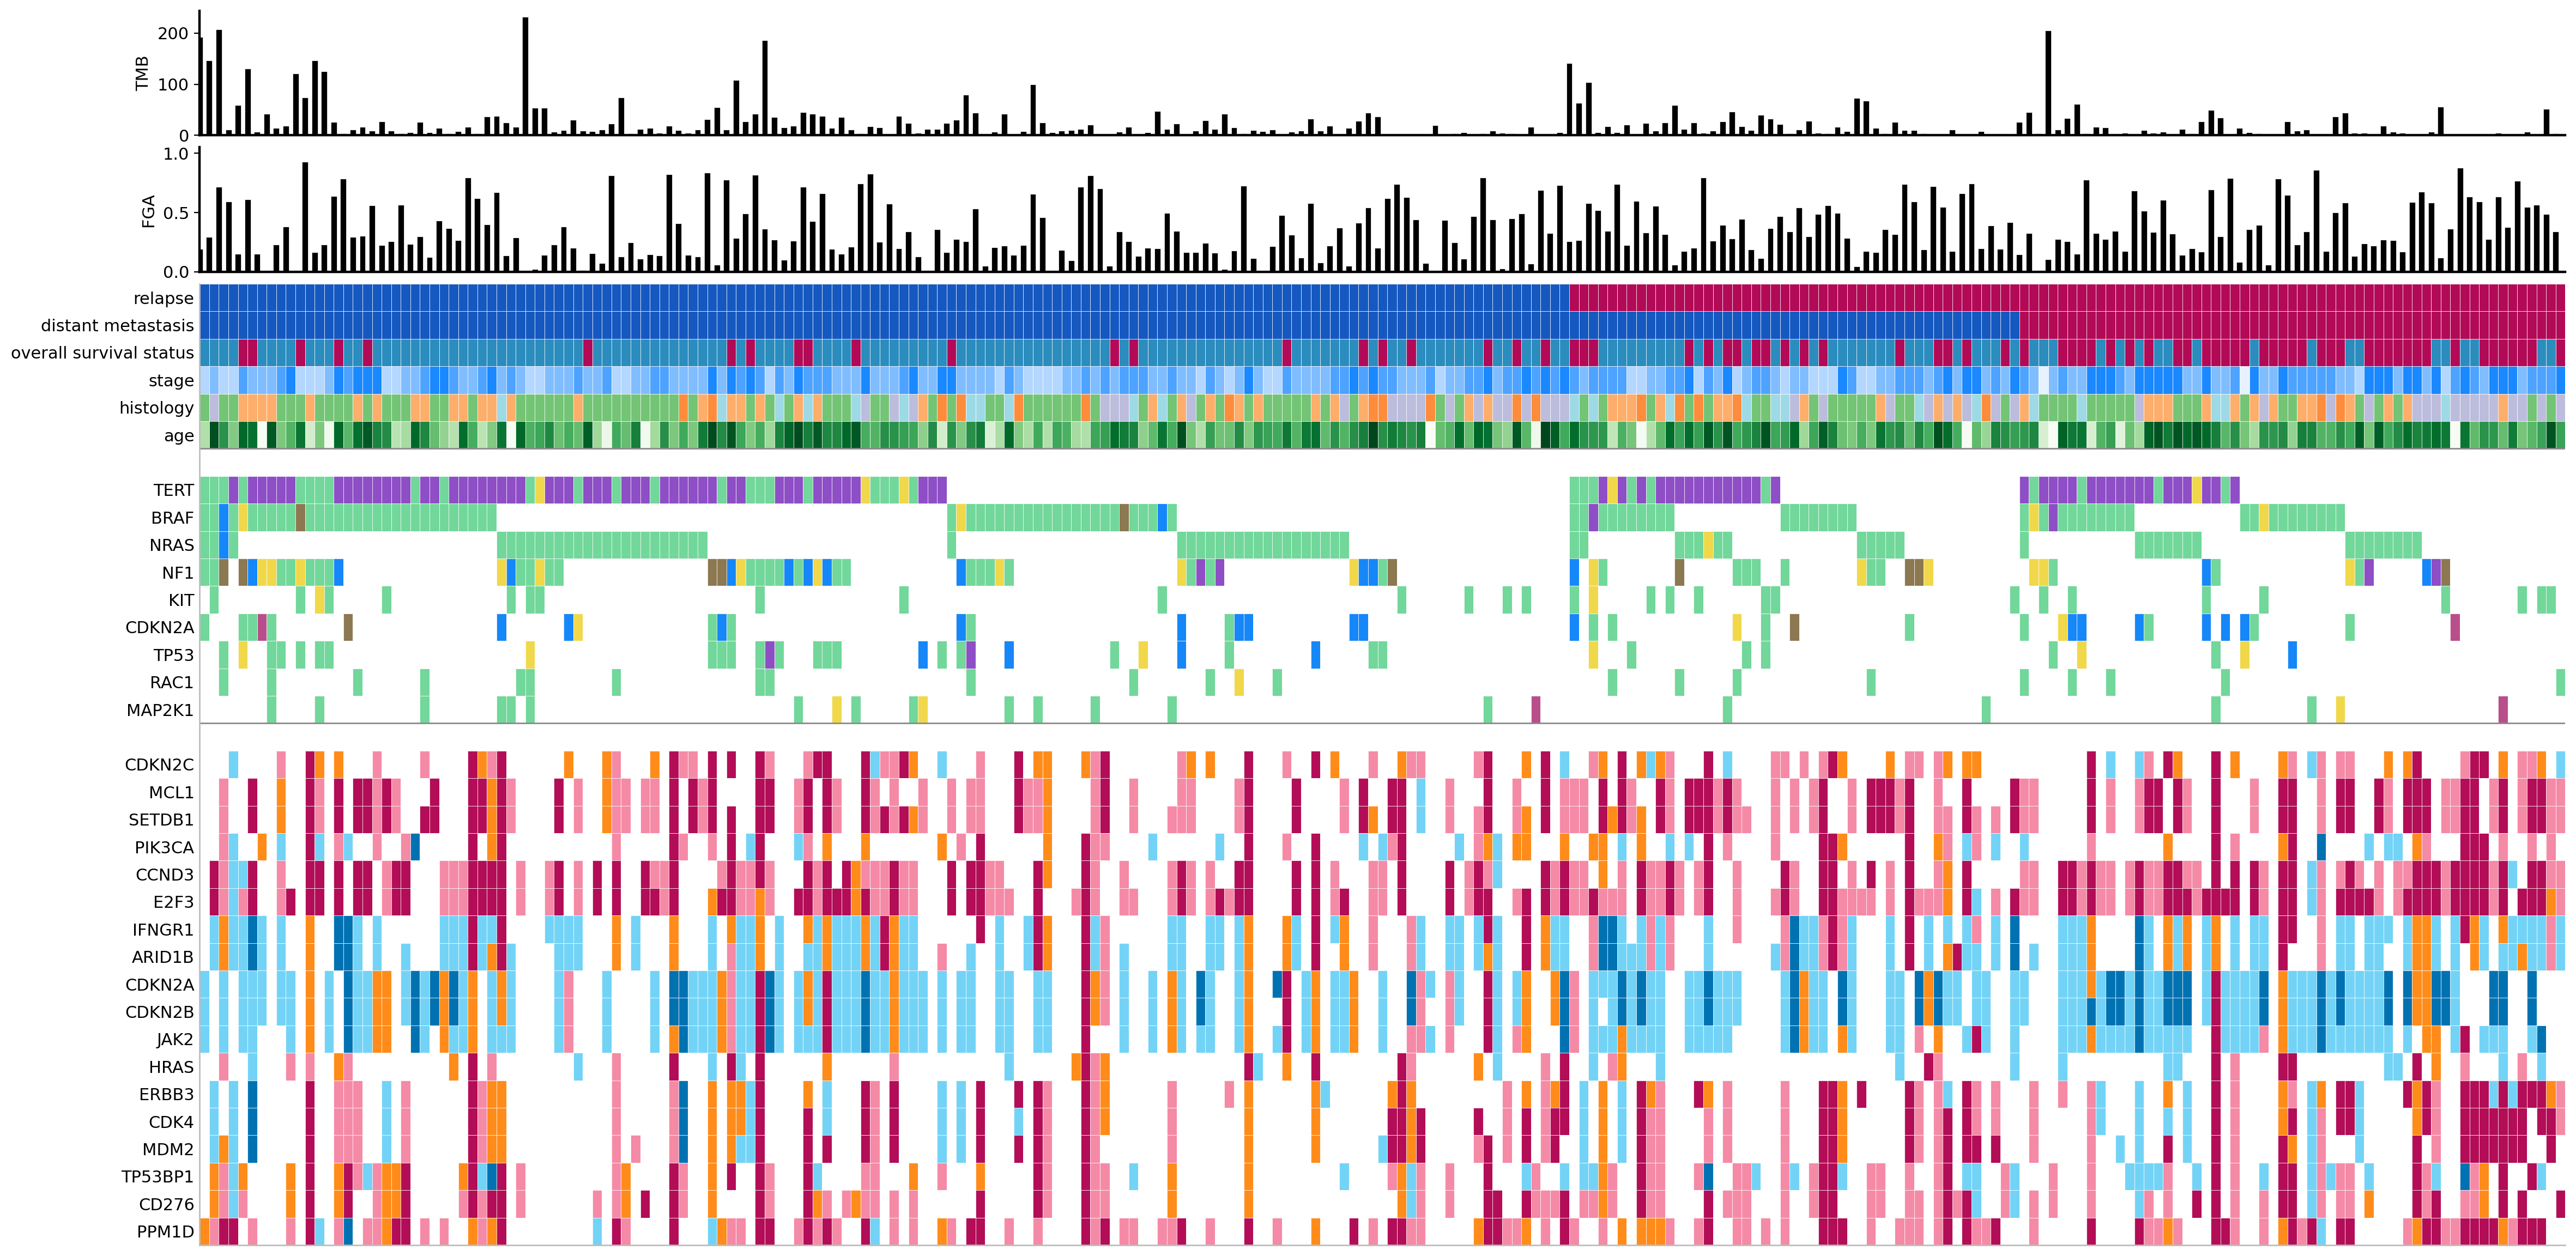

/tmp/ipykernel_3854026/2247102443.py:901: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/tmp/ipykernel_3854026/2247102443.py:901: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/tmp/ipykernel_3854026/2247102443.py:901: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


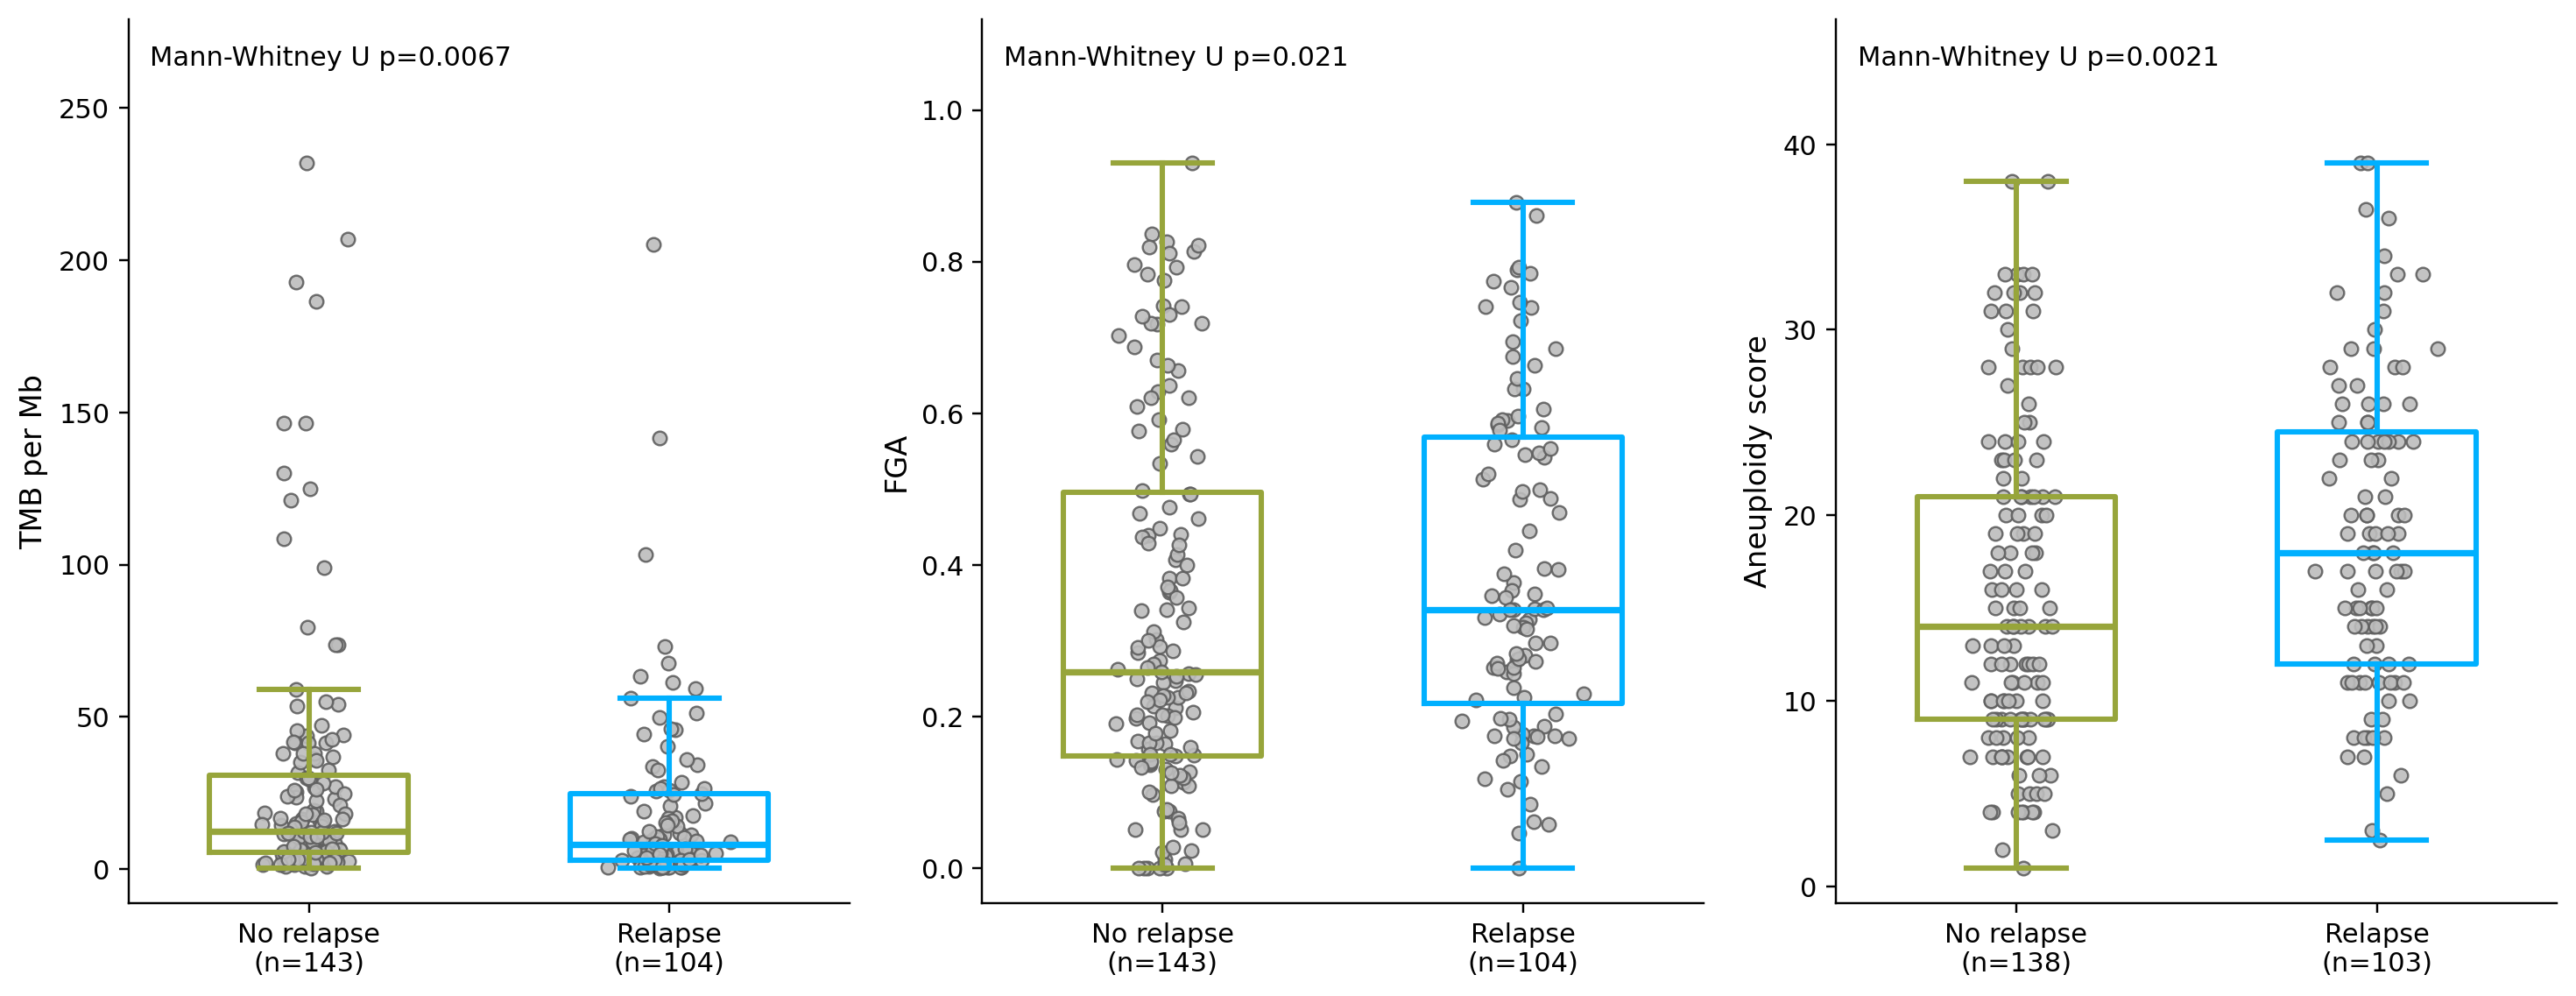

In [16]:
plot_stacked_figure1(bundle)
plot_metric_boxplots(bundle)
